# Kamran Version — Reordered Workflow

This notebook covers the full Nymeria data science pipeline: raw data ingestion from S3, initial EDA, baseline (V1) modeling, text-feature exploration, V2 feature engineering, V2 EDA and dimensionality screening, multi-model comparison (XGBoost / LightGBM / Random Forest), and final dataset export for SageMaker training. Three proposed enhancements are documented at the end.

In [1]:
import json
import io
import os
import re
import tempfile
import warnings

import boto3
import numpy as np
import pandas as pd
import requests
import matplotlib
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
import lightgbm as lgb

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split

import sagemaker

warnings.filterwarnings("ignore")
print("Libraries loaded.")

## 1. Data Ingestion

Initializes required libraries, connects to Amazon S3, and loads the Nymeria manifest file (`Nymeria_download_urls.json`) to retrieve metadata about all available sequences and their associated data files.

In [2]:
s3 = boto3.client("s3")

BUCKET = "sagemaker-bst"
MANIFEST_KEY = "Nymeria_download_urls.json"
TARGET_PREFIX = "nymeria/lightweight/"

# Load manifest from S3
obj = s3.get_object(Bucket=BUCKET, Key=MANIFEST_KEY)
manifest = json.loads(obj["Body"].read().decode("utf-8"))

print(manifest.keys())
print("Number of sequences:", len(manifest["sequences"]))

dict_keys(['sequences', 'sequence_config'])
Number of sequences: 1100


## Parse Manifest

Parses the manifest to extract relevant file types (metadata and narration files), and constructs a structured DataFrame (`df_files`) containing sequence IDs, file names, download URLs, and file metadata for downstream processing.

In [3]:
wanted_types = [
    "metadata_json",
    "narration_atomic_action_csv",
    "narration_activity_summarization_csv",
]

rows = []

for sequence_id, sequence_data in manifest["sequences"].items():
    for file_type in wanted_types:
        if file_type in sequence_data:
            entry = sequence_data[file_type]
            rows.append({
                "sequence_id": sequence_id,
                "file_type": file_type,
                "filename": entry["filename"],
                "file_size_bytes": entry["file_size_bytes"],
                "download_url": entry["download_url"],
                "sha1sum": entry.get("sha1sum")
            })

df_files = pd.DataFrame(rows)

print("Rows:", len(df_files))
print("Unique sequences:", df_files["sequence_id"].nunique())
df_files.head()

Rows: 2809
Unique sequences: 1100


,sequence_id,file_type,filename,file_size_bytes,download_url,sha1sum
0,20230607_s0_james_johnson_act0_e72nhq,metadata_json,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,1367,https://scontent.xx.fbcdn.net/m1/v/t6/An-h6phj...,cf9a90058d0bd4df1d8c56329e33d540d585b22c
1,20230607_s0_james_johnson_act0_e72nhq,narration_atomic_action_csv,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,46391,https://scontent.xx.fbcdn.net/m1/v/t6/An84jpu8...,bb083d6b7f21b2908939550ccb4e5110c0773509
2,20230607_s0_james_johnson_act0_e72nhq,narration_activity_summarization_csv,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,7694,https://scontent.xx.fbcdn.net/m1/v/t6/An_HJbws...,979cfbc78b3a21533739497b93416b787a555524
3,20230607_s0_james_johnson_act1_7xwm28,metadata_json,Nymeria_v0.0_20230607_s0_james_johnson_act1_7x...,1364,https://scontent.xx.fbcdn.net/m1/v/t6/An_hhJNN...,a1798628300502dd21afbb25f075e1207da2e7c5
4,20230607_s0_james_johnson_act1_7xwm28,narration_atomic_action_csv,Nymeria_v0.0_20230607_s0_james_johnson_act1_7x...,56078,https://scontent.xx.fbcdn.net/m1/v/t6/An_nB1rG...,0a9af1cc54c52c617b5efa1c2c72d1e9fa52cca5


## Dataset Profile

Aggregates file counts and sizes by type, providing visibility into dataset distribution and storage footprint across modalities.

In [4]:
summary = (
    df_files.groupby("file_type")["file_size_bytes"]
    .agg(["count", "sum", "mean"])
    .reset_index()
)

summary["sum_mb"] = summary["sum"] / (1024 ** 2)
summary["mean_mb"] = summary["mean"] / (1024 ** 2)

summary

,file_type,count,sum,mean,sum_mb,mean_mb
0,metadata_json,1100,1513984,1376.349091,1.443848,0.001313
1,narration_activity_summarization_csv,864,5743251,6647.281250,5.477191,0.006339
2,narration_atomic_action_csv,845,52533137,62169.392899,50.099504,0.059289


## Check Existing S3 Files

Prepares the full file list for download, checks which files already exist in the S3 bucket using pagination, and estimates how many files still need to be ingested.

In [5]:
df_all = df_files.copy()

print("Files to download:", len(df_all))
print("Sequences covered:", df_all["sequence_id"].nunique())

existing_objects = {}
paginator = s3.get_paginator("list_objects_v2")

for page in paginator.paginate(Bucket=BUCKET, Prefix=TARGET_PREFIX):
    for obj in page.get("Contents", []):
        existing_objects[obj["Key"]] = obj["Size"]

print("Existing objects already in bucket:", len(existing_objects))
print("Remaining estimate:", len(df_all) - len(existing_objects))

Files to download: 2809
Sequences covered: 1100
Existing objects already in bucket: 2810
Remaining estimate: -1


## Stream-to-S3 Helper

Defines a helper function that streams files from external URLs and uploads them to S3 in chunks, enabling efficient and memory-safe data ingestion.

In [6]:
def stream_url_to_s3(url: str, bucket: str, key: str, timeout: int = 120):
    with requests.get(url, stream=True, timeout=timeout) as r:
        r.raise_for_status()
        with tempfile.NamedTemporaryFile(delete=False) as tmp:
            tmp_path = tmp.name
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    tmp.write(chunk)

    s3.upload_file(tmp_path, bucket, key)
    os.remove(tmp_path)

## Download Loop

Iterates through all expected files, checks whether each already exists in S3 with the correct size, and only downloads missing or incomplete files while logging the status of each operation.

In [7]:
download_log = []

for _, row in df_all.iterrows():
    s3_key = f"{TARGET_PREFIX}{row['sequence_id']}/{row['filename']}"
    expected_size = int(row["file_size_bytes"])

    # Skip if already present and size matches
    if s3_key in existing_objects and existing_objects[s3_key] == expected_size:
        download_log.append({
            "sequence_id": row["sequence_id"],
            "file_type": row["file_type"],
            "filename": row["filename"],
            "s3_key": s3_key,
            "status": "already_exists"
        })
        continue

    try:
        stream_url_to_s3(
            url=row["download_url"],
            bucket=BUCKET,
            key=s3_key
        )

        download_log.append({
            "sequence_id": row["sequence_id"],
            "file_type": row["file_type"],
            "filename": row["filename"],
            "s3_key": s3_key,
            "status": "ok"
        })

        # update cache so same-session reruns are safe
        existing_objects[s3_key] = expected_size
        print("Uploaded:", s3_key)

    except Exception as e:
        download_log.append({
            "sequence_id": row["sequence_id"],
            "file_type": row["file_type"],
            "filename": row["filename"],
            "s3_key": s3_key,
            "status": f"error: {str(e)}"
        })
        print("FAILED:", row["filename"], e)

df_log = pd.DataFrame(download_log)
df_log.head()

,sequence_id,file_type,filename,s3_key,status
0,20230607_s0_james_johnson_act0_e72nhq,metadata_json,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,nymeria/lightweight/20230607_s0_james_johnson_...,already_exists
1,20230607_s0_james_johnson_act0_e72nhq,narration_atomic_action_csv,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,nymeria/lightweight/20230607_s0_james_johnson_...,already_exists
2,20230607_s0_james_johnson_act0_e72nhq,narration_activity_summarization_csv,Nymeria_v0.0_20230607_s0_james_johnson_act0_e7...,nymeria/lightweight/20230607_s0_james_johnson_...,already_exists
3,20230607_s0_james_johnson_act1_7xwm28,metadata_json,Nymeria_v0.0_20230607_s0_james_johnson_act1_7x...,nymeria/lightweight/20230607_s0_james_johnson_...,already_exists
4,20230607_s0_james_johnson_act1_7xwm28,narration_atomic_action_csv,Nymeria_v0.0_20230607_s0_james_johnson_act1_7x...,nymeria/lightweight/20230607_s0_james_johnson_...,already_exists


In [8]:
import sagemaker
session = sagemaker.Session()
default_bucket = session.default_bucket()
print("Default bucket:", default_bucket)

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/sagemaker-user/.config/sagemaker/config.yaml
Default bucket: sagemaker-us-east-1-975050245484


In [9]:
csv_buffer = io.StringIO()
df_log.to_csv(csv_buffer, index=False)

s3.put_object(
    Bucket=BUCKET,
    Key=f"{TARGET_PREFIX}download_log_all.csv",
    Body=csv_buffer.getvalue()
)

print("Saved full download log to S3")

Saved full download log to S3


## Load Metadata JSONs from S3

### `read_json_from_s3` Helper

Retrieves a JSON file from S3 and parses it into a Python dictionary, enabling downstream processing of metadata files.

In [10]:
def read_json_from_s3(bucket, key):
    obj = s3.get_object(Bucket=bucket, Key=key)
    return json.loads(obj["Body"].read().decode("utf-8"))

### Scan for Metadata Keys

Scans the S3 bucket for all metadata JSON files within the target prefix and compiles a list of their object keys for batch processing.

In [11]:
metadata_keys = []

for page in paginator.paginate(Bucket=BUCKET, Prefix=TARGET_PREFIX):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        if key.endswith("_metadata.json"):
            metadata_keys.append(key)

print("Metadata files found:", len(metadata_keys))
metadata_keys[:5]

Metadata files found: 1100


['nymeria/lightweight/20230607_s0_james_johnson_act0_e72nhq/Nymeria_v0.0_20230607_s0_james_johnson_act0_e72nhq_metadata.json',
 'nymeria/lightweight/20230607_s0_james_johnson_act1_7xwm28/Nymeria_v0.0_20230607_s0_james_johnson_act1_7xwm28_metadata.json',
 'nymeria/lightweight/20230607_s0_james_johnson_act2_yhbvpa/Nymeria_v0.0_20230607_s0_james_johnson_act2_yhbvpa_metadata.json',
 'nymeria/lightweight/20230607_s0_james_johnson_act3_ifj2gc/Nymeria_v0.0_20230607_s0_james_johnson_act3_ifj2gc_metadata.json',
 'nymeria/lightweight/20230607_s1_barbara_wheeler_act0_cvxtsi/Nymeria_v0.0_20230607_s1_barbara_wheeler_act0_cvxtsi_metadata.json']

### Load Metadata into DataFrame

Iterates through all metadata files, loads each JSON record into memory, and consolidates them into a structured DataFrame for analysis and feature engineering.

In [12]:
metadata_rows = []

for key in metadata_keys:
    try:
        record = read_json_from_s3(BUCKET, key)
        record["s3_key"] = key
        metadata_rows.append(record)
    except Exception as e:
        print("FAILED:", key, e)

df_meta = pd.DataFrame(metadata_rows)

print(df_meta.shape)
df_meta.head()

(1100, 45)


,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,...,atomic_action,activity_summarization,participant_gender,participant_height_cm,participant_weight_kg,participant_bmi,participant_age_group,participant_ethnicity,participant_xsens_suit_size,s3_key
0,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,...,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...
1,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act1,7xwm28,Loc_04,S1-Relax_at_home,862.262,...,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...
2,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.662,...,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...
3,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.668,...,True,True,Female,158.0,49.0,20.1,25-30,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...
4,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act0,cvxtsi,Loc_04,S14-By_my_desk,973.378,...,True,True,Male,195.0,96.0,25.2,18-24,African American,XXL,nymeria/lightweight/20230607_s1_barbara_wheele...


## Atomic Narration CSVs

### `read_csv_from_s3` Helper

Retrieves a CSV file from S3 and loads it directly into a pandas DataFrame for downstream processing.

In [13]:
def read_csv_from_s3(bucket, key):
    obj = s3.get_object(Bucket=bucket, Key=key)
    return pd.read_csv(io.BytesIO(obj["Body"].read()))

### Scan for Atomic Narration Keys

Scans the S3 bucket and identifies all atomic narration CSV files, storing their object keys for batch ingestion.

In [14]:
atomic_keys = []

for page in paginator.paginate(Bucket=BUCKET, Prefix=TARGET_PREFIX):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        if key.endswith("_narration_atomic_action.csv"):
            atomic_keys.append(key)

print("Atomic narration files:", len(atomic_keys))
atomic_keys[:5]

Atomic narration files: 845


['nymeria/lightweight/20230607_s0_james_johnson_act0_e72nhq/Nymeria_v0.0_20230607_s0_james_johnson_act0_e72nhq_narration_atomic_action.csv',
 'nymeria/lightweight/20230607_s0_james_johnson_act1_7xwm28/Nymeria_v0.0_20230607_s0_james_johnson_act1_7xwm28_narration_atomic_action.csv',
 'nymeria/lightweight/20230607_s0_james_johnson_act2_yhbvpa/Nymeria_v0.0_20230607_s0_james_johnson_act2_yhbvpa_narration_atomic_action.csv',
 'nymeria/lightweight/20230607_s0_james_johnson_act3_ifj2gc/Nymeria_v0.0_20230607_s0_james_johnson_act3_ifj2gc_narration_atomic_action.csv',
 'nymeria/lightweight/20230607_s1_barbara_wheeler_act0_cvxtsi/Nymeria_v0.0_20230607_s1_barbara_wheeler_act0_cvxtsi_narration_atomic_action.csv']

### Load Atomic Narrations into DataFrame

Iterates through all atomic narration files, loads each into a DataFrame, and concatenates them into a single unified dataset for analysis.

In [15]:
atomic_frames = []

for key in atomic_keys:
    try:
        tmp = read_csv_from_s3(BUCKET, key)
        tmp["s3_key"] = key
        atomic_frames.append(tmp)
    except Exception as e:
        print("FAILED:", key, e)

df_atomic = pd.concat(atomic_frames, ignore_index=True) if atomic_frames else pd.DataFrame()

print(df_atomic.shape)
df_atomic.head()

(173616, 8)


,request_id,gaia_id,start_time,end_time,annotator,creation_time,Describe my atomic actions,s3_key
0,4dad79c8-6d81-4069-9c8a-cce79a079ba2,1.161925e+15,5831.823751,5836.822947,7.019527e+15,1.720073e+09,C is standing in the foyer while talking to he...,nymeria/lightweight/20230607_s0_james_johnson_...
1,4dad79c8-6d81-4069-9c8a-cce79a079ba2,1.161925e+15,5836.822947,5841.822149,7.019527e+15,1.720073e+09,C is walking towards the hallway then turns he...,nymeria/lightweight/20230607_s0_james_johnson_...
2,4dad79c8-6d81-4069-9c8a-cce79a079ba2,1.161925e+15,5841.822149,5846.821344,7.019527e+15,1.720073e+09,C is standing in the hallway as she opens and ...,nymeria/lightweight/20230607_s0_james_johnson_...
3,4dad79c8-6d81-4069-9c8a-cce79a079ba2,1.161925e+15,5846.821344,5851.820544,7.019527e+15,1.720073e+09,C is standing in the hallway as she opens the ...,nymeria/lightweight/20230607_s0_james_johnson_...
4,4dad79c8-6d81-4069-9c8a-cce79a079ba2,1.161925e+15,5851.820544,5856.819743,7.019527e+15,1.720073e+09,"In the hallway, C slightly turns her body to t...",nymeria/lightweight/20230607_s0_james_johnson_...


## Extract Sequence IDs

Extracts a unique sequence identifier from each file path and assigns it to both metadata and atomic datasets, enabling consistent joining across data sources.

# Extracts a unique sequence identifier from each file path and assigns it to both metadata and atomic datasets, enabling consistent joining across data sources.

In [16]:
import re

def extract_sequence_id(s3_key):
    match = re.search(r"lightweight/(.*?)/", s3_key)
    return match.group(1) if match else None

df_meta["sequence_id"] = df_meta["s3_key"].apply(extract_sequence_id)
df_atomic["sequence_id"] = df_atomic["s3_key"].apply(extract_sequence_id)

df_meta[["sequence_id"]].head()
df_atomic[["sequence_id"]].head()

,sequence_id
0,20230607_s0_james_johnson_act0_e72nhq
1,20230607_s0_james_johnson_act0_e72nhq
2,20230607_s0_james_johnson_act0_e72nhq
3,20230607_s0_james_johnson_act0_e72nhq
4,20230607_s0_james_johnson_act0_e72nhq


## Aggregate Atomic Narrations to Sequence Level

Transforms atomic-level data into sequence-level features by computing action durations, converting narration text into numerical length-based features, and aggregating interaction metrics such as total actions, unique actions, and average/median action duration.

In [17]:
# duration per atomic action row
df_atomic["action_duration"] = df_atomic["end_time"] - df_atomic["start_time"]

# text length feature
text_col = "Describe my atomic actions"
df_atomic["action_length"] = df_atomic[text_col].astype(str).str.len()

df_atomic_agg = df_atomic.groupby("sequence_id").agg(
    num_actions=("request_id", "count"),
    unique_actions=(text_col, "nunique"),
    avg_action_duration=("action_duration", "mean"),
    median_action_duration=("action_duration", "median")
).reset_index()

df_atomic_text = df_atomic.groupby("sequence_id").agg(
    avg_action_length=("action_length", "mean"),
    max_action_length=("action_length", "max")
).reset_index()

print(df_atomic_agg.shape)
df_atomic_agg.head()

(845, 5)


,sequence_id,num_actions,unique_actions,avg_action_duration,median_action_duration
0,20230607_s0_james_johnson_act0_e72nhq,170,158,4.974106,4.999199
1,20230607_s0_james_johnson_act1_7xwm28,179,134,2.450632,4.999200
2,20230607_s0_james_johnson_act2_yhbvpa,180,173,4.922546,4.999200
3,20230607_s0_james_johnson_act3_ifj2gc,171,152,4.971134,4.999199
4,20230607_s1_barbara_wheeler_act0_cvxtsi,204,141,4.954436,4.999200


## 2. Initial EDA (V1)

In [18]:
def missing_summary(df):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df)) * 100
    return pd.DataFrame({
        "missing_count": missing,
        "missing_pct": missing_pct
    }).sort_values(by="missing_pct", ascending=False)

missing_summary(df_meta).head(10)
missing_summary(df_atomic).head(10)

,missing_count,missing_pct
Describe my atomic actions,10,0.00576
gaia_id,0,0.00000
request_id,0,0.00000
start_time,0,0.00000
end_time,0,0.00000
annotator,0,0.00000
creation_time,0,0.00000
s3_key,0,0.00000
sequence_id,0,0.00000
action_duration,0,0.00000


## Create V1 Modeling Dataset

Merges the aggregated narration features with the metadata table, filters to rows with all required modeling fields present, and produces the final cleaned sequence-level dataset for analysis.

## EDA — V1 Feature Distributions

In [19]:
# Create final dataset
df_model = df_meta.merge(df_atomic_agg, on="sequence_id", how="left")
df_model = df_model.merge(df_atomic_text, on="sequence_id", how="left")

print("Merged shape:", df_model.shape)

required_cols = [
    "action_duration_sec",
    "head_trajectory_m",
    "head_duration_sec",
    "num_actions",
    "unique_actions",
    "avg_action_duration",
    "median_action_duration",
    "avg_action_length",
    "max_action_length",
    "participant_height_cm",
    "participant_weight_kg",
    "participant_bmi",
]

df_model_clean = df_model.dropna(subset=required_cols).copy()

print("Clean shape:", df_model_clean.shape)
df_model_clean.head()

Merged shape: (1100, 52)
Clean shape: (845, 52)


,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,...,participant_ethnicity,participant_xsens_suit_size,s3_key,sequence_id,num_actions,unique_actions,avg_action_duration,median_action_duration,avg_action_length,max_action_length
0,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,...,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...,20230607_s0_james_johnson_act0_e72nhq,170.0,158.0,4.974106,4.999199,162.258824,457.0
1,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act1,7xwm28,Loc_04,S1-Relax_at_home,862.262,...,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...,20230607_s0_james_johnson_act1_7xwm28,179.0,134.0,2.450632,4.999200,202.815642,521.0
2,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.662,...,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...,20230607_s0_james_johnson_act2_yhbvpa,180.0,173.0,4.922546,4.999200,203.700000,439.0
3,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.668,...,East Asian,M,nymeria/lightweight/20230607_s0_james_johnson_...,20230607_s0_james_johnson_act3_ifj2gc,171.0,152.0,4.971134,4.999199,246.877193,570.0
4,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act0,cvxtsi,Loc_04,S14-By_my_desk,973.378,...,African American,XXL,nymeria/lightweight/20230607_s1_barbara_wheele...,20230607_s1_barbara_wheeler_act0_cvxtsi,204.0,141.0,4.954436,4.999200,222.710784,566.0


## 3. V1 Modeling

### Define Target and Features

Constructs the initial discomfort proxy using high-duration and high head-movement thresholds, selects the modeling features, and separates the dataset into predictors (X) and target labels.

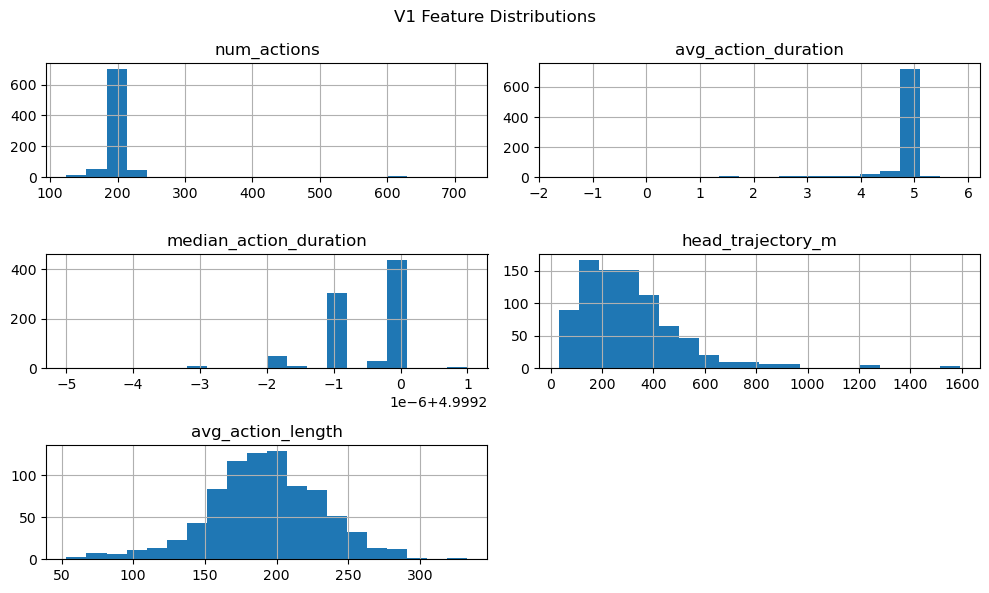

In [20]:
import matplotlib.pyplot as plt

v1_eda_cols = [
    "num_actions",
    "avg_action_duration",
    "median_action_duration",
    "head_trajectory_m",
    "avg_action_length"
]

df_model_clean[v1_eda_cols].hist(bins=20, figsize=(10, 6))
plt.suptitle("V1 Feature Distributions")
plt.tight_layout()
plt.show()

In [21]:
df_model_clean[v1_eda_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_actions,845.0,205.462722,6.336498e+01,124.000000,191.000000,195.000000,203.000000,719.000000
avg_action_duration,845.0,4.739668,6.960302e-01,-1.630576,4.847101,4.933747,4.976923,5.848637
median_action_duration,845.0,4.999199,6.925455e-07,4.999195,4.999199,4.999200,4.999200,4.999201
head_trajectory_m,845.0,310.332450,2.047677e+02,31.920000,171.410000,274.770000,397.370000,1593.100000
avg_action_length,845.0,192.060897,3.998895e+01,53.390476,168.029703,192.015544,217.515464,333.067708


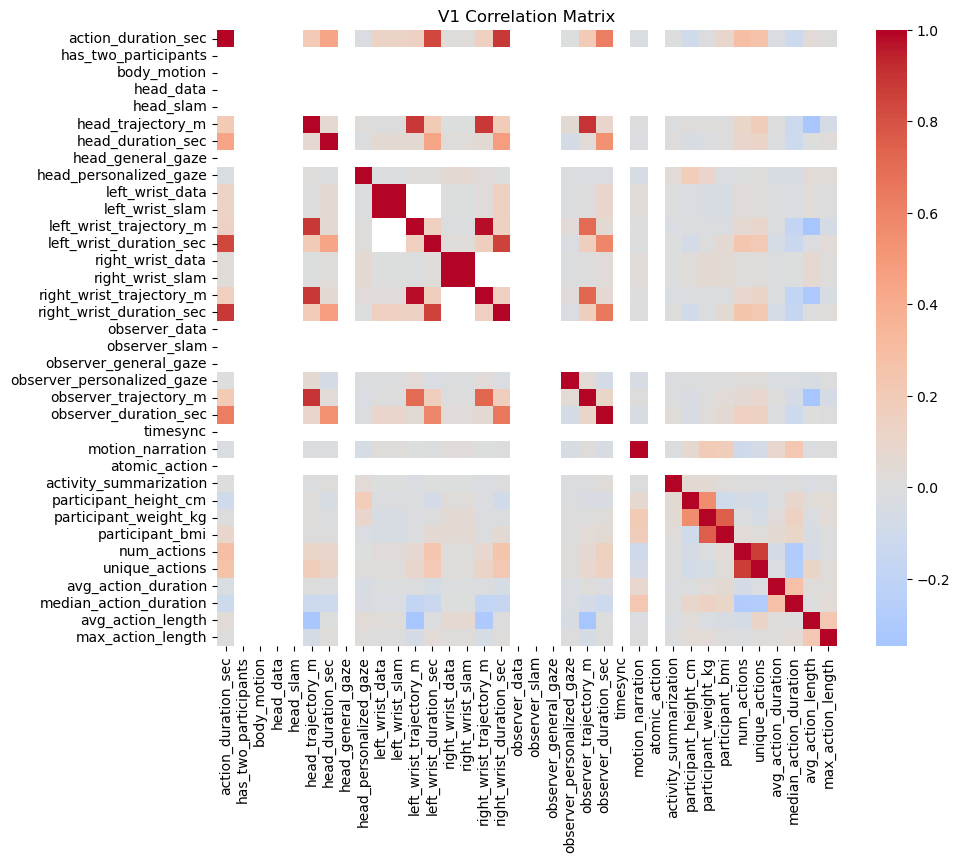

In [22]:
corr_v1 = df_model_clean.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_v1, cmap="coolwarm", center=0)
plt.title("V1 Correlation Matrix")
plt.show()

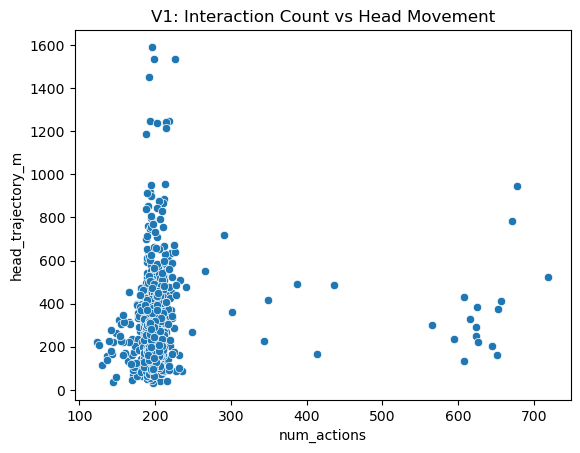

In [23]:
sns.scatterplot(
    data=df_model_clean,
    x="num_actions",
    y="head_trajectory_m"
)
plt.title("V1: Interaction Count vs Head Movement")
plt.show()

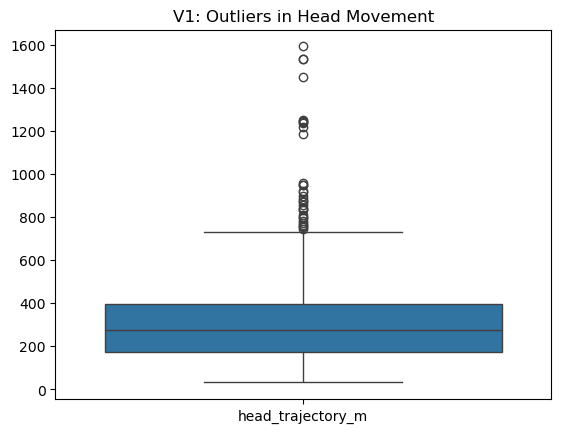

In [24]:
sns.boxplot(data=df_model_clean[["head_trajectory_m"]])
plt.title("V1: Outliers in Head Movement")
plt.show()

# Create target, select features, split train/validation/test

### V1 Baseline — Random Forest

In [25]:
# Create target feature proxy for discomfort
# Proxy: longer session/action duration + high head movement
df_model_clean["discomfort_proxy"] = (
    (df_model_clean["action_duration_sec"] > df_model_clean["action_duration_sec"].quantile(0.75)) &
    (df_model_clean["head_trajectory_m"] > df_model_clean["head_trajectory_m"].quantile(0.75))
).astype(int)

# Feature selection
features = [
    "head_duration_sec",
    "left_wrist_trajectory_m",
    "left_wrist_duration_sec",
    "right_wrist_trajectory_m",
    "right_wrist_duration_sec",
    "observer_trajectory_m",
    "observer_duration_sec",
    "num_actions",
    "unique_actions",
    "avg_action_duration",
    "median_action_duration",
    "avg_action_length",
    "max_action_length",
    "participant_height_cm",
    "participant_weight_kg",
    "participant_bmi",
]

X = df_model_clean[features].copy()
y = df_model_clean["discomfort_proxy"].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Target distribution:")
print(y.value_counts())

Feature matrix shape: (845, 16)
Target shape: (845,)
Target distribution:
discomfort_proxy
0    762
1     83
Name: count, dtype: int64


### V1 Debug Notes

We constructed a proxy target variable representing potential discomfort using high-duration sessions and elevated head movement. Initial models showed near-perfect validation performance, indicating potential leakage due to overlap between target construction and input features. To address this, we refined the feature set by removing directly correlated variables, ensuring the model learns patterns rather than reconstructing the label.

In [26]:
from sklearn.model_selection import train_test_split

# 80 / 10 / 10 split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (676, 16) (676,)
Validation: (84, 16) (84,)
Test: (85, 16) (85,)


## 4. Text Feature Exploration

We explore the narration text as an alternative labeling signal for discomfort, using bigrams and behavior keyword counts.

In [27]:
train_df = pd.concat([X_train, y_train.rename("discomfort_proxy")], axis=1)
val_df = pd.concat([X_val, y_val.rename("discomfort_proxy")], axis=1)
test_df = pd.concat([X_test, y_test.rename("discomfort_proxy")], axis=1)

def upload_df_to_s3(df, bucket, key):
    buffer = io.StringIO()
    df.to_csv(buffer, index=False)
    s3.put_object(Bucket=bucket, Key=key, Body=buffer.getvalue())

upload_df_to_s3(train_df, BUCKET, "nymeria/train/train.csv")
upload_df_to_s3(val_df, BUCKET, "nymeria/validation/validation.csv")
upload_df_to_s3(test_df, BUCKET, "nymeria/test/test.csv")

print("Saved train / validation / test to S3")

Saved train / validation / test to S3


In [28]:
print(y.value_counts(normalize=True))

discomfort_proxy
0    0.901775
1    0.098225
Name: proportion, dtype: float64


# Quick local baseline model in the notebook

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)

val_pred = rf.predict(X_val)
test_pred = rf.predict(X_test)

print("Validation confusion matrix:")
print(confusion_matrix(y_val, val_pred))
print(classification_report(y_val, val_pred))

print("Test confusion matrix:")
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))

Validation confusion matrix:
[[76  0]
 [ 1  7]]
              precision    recall  f1-score   support

           0       0.99      1.00      0.99        76
           1       1.00      0.88      0.93         8

    accuracy                           0.99        84
   macro avg       0.99      0.94      0.96        84
weighted avg       0.99      0.99      0.99        84

Test confusion matrix:
[[75  1]
 [ 3  6]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        76
           1       0.86      0.67      0.75         9

    accuracy                           0.95        85
   macro avg       0.91      0.83      0.86        85
weighted avg       0.95      0.95      0.95        85



### Text Complexity Features

# Model Performance & Evaluation
After removing features directly used in target construction, model performance became more realistic. The Random Forest classifier achieved strong performance on the majority class (no discomfort), but showed reduced recall for the minority class (discomfort events), particularly on the test set (recall = 0.67). This indicates that while the model can identify general behavioral patterns, it struggles to consistently detect less frequent discomfort scenarios. The drop from validation to test performance suggests mild overfitting and highlights the challenge of class imbalance in real-world datasets.

# Explore other ways to more accurately label and use discomfort in a model to predict - Rely on participant descriptions

In [30]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),  # bigrams
    min_df=10            # ignore rare phrases
)

X_text = vectorizer.fit_transform(df_atomic[text_col].dropna())

bigram_counts = X_text.sum(axis=0).A1
bigrams = vectorizer.get_feature_names_out()

df_bigrams = pd.DataFrame({
    "bigram": bigrams,
    "count": bigram_counts
}).sort_values(by="count", ascending=False)

df_bigrams.head(30)

,bigram,count
17536,right hand,115015
11948,left hand,85812
12542,living area,35229
12544,living room,20900
19685,standing kitchen,18723
22183,turns right,18490
22175,turns left,18262
8594,hand holding,16583
22453,using right,12763
22420,using hands,11820


In [31]:
behavior_keywords = {
    "hesitation": ["pause", "slow", "stop", "wait"],
    "searching": ["look", "search", "scan", "turn"],
    "adjustment": ["adjust", "reposition", "lean", "bend"],
    "interaction": ["grab", "open", "hold", "pick"]
}

def behavior_features(text):
    text = str(text).lower()
    features = {}
    for category, words in behavior_keywords.items():
        features[f"{category}_count"] = sum(w in text for w in words)
    return pd.Series(features)

df_atomic_behavior = df_atomic[text_col].apply(behavior_features)

df_atomic = pd.concat([df_atomic, df_atomic_behavior], axis=1)

In [32]:
df_behavior_agg = df_atomic.groupby("sequence_id").agg({
    "hesitation_count": "sum",
    "searching_count": "sum",
    "adjustment_count": "sum",
    "interaction_count": "sum"
}).reset_index()

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=100
)

tfidf_matrix = tfidf.fit_transform(df_atomic[text_col].fillna(""))

df_tfidf = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

df_tfidf["sequence_id"] = df_atomic["sequence_id"].values

df_tfidf_agg = df_tfidf.groupby("sequence_id").mean().reset_index()

# Version 2 Data prep for training and modeling

In [34]:
df_model_v1 = df_model.copy()
df_model_v2 = df_model.copy()

In [35]:
text_col = "Describe my atomic actions"

def text_complexity_features(text):
    text = str(text)
    words = text.split()
    num_words = len(words)
    unique_words = len(set(words))
    avg_word_length = sum(len(w) for w in words) / num_words if num_words > 0 else 0

    return pd.Series({
        "text_len_words": num_words,
        "text_unique_words": unique_words,
        "text_diversity": unique_words / num_words if num_words > 0 else 0,
        "avg_word_length": avg_word_length
    })

df_atomic_v2 = df_atomic.copy()
df_atomic_text_features_v2 = df_atomic_v2[text_col].apply(text_complexity_features)
df_atomic_v2 = pd.concat([df_atomic_v2, df_atomic_text_features_v2], axis=1)

df_atomic_v2[[text_col, "text_len_words", "text_unique_words", "text_diversity", "avg_word_length"]].head()

,Describe my atomic actions,text_len_words,text_unique_words,text_diversity,avg_word_length
0,C is standing in the foyer while talking to he...,34.0,26.0,0.764706,4.147059
1,C is walking towards the hallway then turns he...,27.0,22.0,0.814815,4.259259
2,C is standing in the hallway as she opens and ...,23.0,19.0,0.826087,4.347826
3,C is standing in the hallway as she opens the ...,62.0,37.0,0.596774,4.048387
4,"In the hallway, C slightly turns her body to t...",62.0,32.0,0.516129,4.048387


In [36]:
df_atomic_v2["action_duration"] = df_atomic_v2["end_time"] - df_atomic_v2["start_time"]

df_atomic_agg_v2 = df_atomic_v2.groupby("sequence_id").agg(
    num_actions=("request_id", "count"),
    unique_actions=(text_col, "nunique"),
    avg_action_duration=("action_duration", "mean"),
    median_action_duration=("action_duration", "median"),
    text_len_words=("text_len_words", "sum"),
    text_unique_words=("text_unique_words", "mean"),
    text_diversity=("text_diversity", "mean"),
    avg_word_length=("avg_word_length", "mean"),
).reset_index()

df_atomic_text_v2 = df_atomic_v2.groupby("sequence_id").agg(
    avg_action_length=("action_length", "mean"),
    max_action_length=("action_length", "max")
).reset_index()

print(df_atomic_agg_v2.shape)
df_atomic_agg_v2.head()

(845, 9)


,sequence_id,num_actions,unique_actions,avg_action_duration,median_action_duration,text_len_words,text_unique_words,text_diversity,avg_word_length
0,20230607_s0_james_johnson_act0_e72nhq,170,158,4.974106,4.999199,5367.0,22.682353,0.781825,4.231626
1,20230607_s0_james_johnson_act1_7xwm28,179,134,2.450632,4.999200,7093.0,27.480447,0.736426,4.097402
2,20230607_s0_james_johnson_act2_yhbvpa,180,173,4.922546,4.999200,6854.0,26.822222,0.737148,4.378817
3,20230607_s0_james_johnson_act3_ifj2gc,171,152,4.971134,4.999199,8512.0,32.175439,0.692621,3.981826
4,20230607_s1_barbara_wheeler_act0_cvxtsi,204,141,4.954436,4.999200,8769.0,28.602941,0.701973,4.199874


In [37]:
df_model_v2 = df_meta.merge(df_atomic_agg_v2, on="sequence_id", how="left")
df_model_v2 = df_model_v2.merge(df_atomic_text_v2, on="sequence_id", how="left")

print("Merged V2 shape:", df_model_v2.shape)
df_model_v2.head()

Merged V2 shape: (1100, 56)


,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,...,num_actions,unique_actions,avg_action_duration,median_action_duration,text_len_words,text_unique_words,text_diversity,avg_word_length,avg_action_length,max_action_length
0,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,...,170.0,158.0,4.974106,4.999199,5367.0,22.682353,0.781825,4.231626,162.258824,457.0
1,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act1,7xwm28,Loc_04,S1-Relax_at_home,862.262,...,179.0,134.0,2.450632,4.999200,7093.0,27.480447,0.736426,4.097402,202.815642,521.0
2,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.662,...,180.0,173.0,4.922546,4.999200,6854.0,26.822222,0.737148,4.378817,203.700000,439.0
3,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.668,...,171.0,152.0,4.971134,4.999199,8512.0,32.175439,0.692621,3.981826,246.877193,570.0
4,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act0,cvxtsi,Loc_04,S14-By_my_desk,973.378,...,204.0,141.0,4.954436,4.999200,8769.0,28.602941,0.701973,4.199874,222.710784,566.0


In [38]:
df_model_v2["efficiency_score"] = df_model_v2["num_actions"] / (df_model_v2["action_duration_sec"] + 1)
df_model_v2["fragmentation"] = df_model_v2["num_actions"] / (df_model_v2["unique_actions"] + 1)
df_model_v2["motion_intensity"] = df_model_v2["head_trajectory_m"] / (df_model_v2["action_duration_sec"] + 1)
df_model_v2["avg_words_per_action"] = df_model_v2["text_len_words"] / (df_model_v2["num_actions"] + 1)

df_model_v2["wrist_motion_total"] = (
    df_model_v2["left_wrist_trajectory_m"].fillna(0) +
    df_model_v2["right_wrist_trajectory_m"].fillna(0)
)

df_model_v2["wrist_motion_intensity"] = (
    df_model_v2["wrist_motion_total"] / (df_model_v2["action_duration_sec"] + 1)
)

df_model_v2[[
    "sequence_id",
    "efficiency_score",
    "fragmentation",
    "motion_intensity",
    "avg_words_per_action",
    "wrist_motion_intensity"
]].head()

,sequence_id,efficiency_score,fragmentation,motion_intensity,avg_words_per_action,wrist_motion_intensity
0,20230607_s0_james_johnson_act0_e72nhq,0.206027,1.069182,0.284111,31.385965,0.680131
1,20230607_s0_james_johnson_act1_7xwm28,0.207353,1.325926,0.104244,39.405556,0.270347
2,20230607_s0_james_johnson_act2_yhbvpa,0.209141,1.034483,0.215497,37.867403,0.502555
3,20230607_s0_james_johnson_act3_ifj2gc,0.207105,1.117647,0.085192,49.488372,0.281723
4,20230607_s1_barbara_wheeler_act0_cvxtsi,0.209364,1.436620,0.137236,42.775610,0.310454


## V2 target creation and final dataset

Create the refined discomfort proxy, define the V2 required columns and feature list, and then build the cleaned V2 modeling table before running V2 EDA.

In [39]:
df_model_v2["discomfort_proxy"] = (
    (df_model_v2["efficiency_score"] > df_model_v2["efficiency_score"].quantile(0.75)) |
    (df_model_v2["fragmentation"] > df_model_v2["fragmentation"].quantile(0.75)) |
    (df_model_v2["motion_intensity"] > df_model_v2["motion_intensity"].quantile(0.75))
).astype(int)

print(df_model_v2["discomfort_proxy"].value_counts(dropna=False))
print(df_model_v2["discomfort_proxy"].value_counts(normalize=True, dropna=False))

discomfort_proxy
0    569
1    531
Name: count, dtype: int64
discomfort_proxy
0    0.517273
1    0.482727
Name: proportion, dtype: float64


In [40]:
required_cols_v2 = [
    "head_trajectory_m",
    "head_duration_sec",
    "left_wrist_trajectory_m",
    "left_wrist_duration_sec",
    "right_wrist_trajectory_m",
    "right_wrist_duration_sec",
    "observer_trajectory_m",
    "observer_duration_sec",
    "num_actions",
    "unique_actions",
    "avg_action_duration",
    "median_action_duration",
    "avg_action_length",
    "max_action_length",
    "text_len_words",
    "text_unique_words",
    "text_diversity",
    "avg_word_length",
    "efficiency_score",
    "fragmentation",
    "motion_intensity",
    "avg_words_per_action",
    "wrist_motion_total",
    "wrist_motion_intensity",
    "participant_height_cm",
    "participant_weight_kg",
    "participant_bmi",
    "discomfort_proxy",
]

df_model_v2_clean = df_model_v2.dropna(subset=required_cols_v2).copy()

print("Clean V2 shape:", df_model_v2_clean.shape)
df_model_v2_clean.head()

Clean V2 shape: (841, 63)


,license,version,date,session_id,fake_name,act_id,uid,location,script,action_duration_sec,...,avg_word_length,avg_action_length,max_action_length,efficiency_score,fragmentation,motion_intensity,avg_words_per_action,wrist_motion_total,wrist_motion_intensity,discomfort_proxy
0,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act0,e72nhq,Loc_04,S14-By_my_desk,824.135,...,4.231626,162.258824,457.0,0.206027,1.069182,0.284111,31.385965,561.20,0.680131,0
1,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act1,7xwm28,Loc_04,S1-Relax_at_home,862.262,...,4.097402,202.815642,521.0,0.207353,1.325926,0.104244,39.405556,233.38,0.270347,1
2,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act2,yhbvpa,Loc_04,S19-Fresh_air,859.662,...,4.378817,203.700000,439.0,0.209141,1.034483,0.215497,37.867403,432.53,0.502555,0
3,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s0,james_johnson,act3,ifj2gc,Loc_04,S12-Game_night,824.668,...,3.981826,246.877193,570.0,0.207105,1.117647,0.085192,49.488372,232.61,0.281723,0
4,CC BY-NC 4.0 (https://creativecommons.org/lice...,0.0,20230607,s1,barbara_wheeler,act0,cvxtsi,Loc_04,S14-By_my_desk,973.378,...,4.199874,222.710784,566.0,0.209364,1.436620,0.137236,42.775610,302.50,0.310454,1


In [41]:
features_v2 = [
    "head_trajectory_m",
    "head_duration_sec",
    "left_wrist_trajectory_m",
    "left_wrist_duration_sec",
    "right_wrist_trajectory_m",
    "right_wrist_duration_sec",
    "observer_trajectory_m",
    "observer_duration_sec",
    "num_actions",
    "unique_actions",
    "avg_action_duration",
    "median_action_duration",
    "avg_action_length",
    "max_action_length",
    "text_len_words",
    "text_unique_words",
    "text_diversity",
    "avg_word_length",
    "efficiency_score",
    "fragmentation",
    "motion_intensity",
    "avg_words_per_action",
    "wrist_motion_total",
    "wrist_motion_intensity",
    "participant_height_cm",
    "participant_weight_kg",
    "participant_bmi",
]

X_v2 = df_model_v2_clean[features_v2].copy()
y_v2 = df_model_v2_clean["discomfort_proxy"].copy()

print("Feature matrix V2 shape:", X_v2.shape)
print("Target V2 shape:", y_v2.shape)
print(y_v2.value_counts())
print(y_v2.value_counts(normalize=True))

Feature matrix V2 shape: (841, 27)
Target V2 shape: (841,)
discomfort_proxy
1    505
0    336
Name: count, dtype: int64
discomfort_proxy
1    0.600476
0    0.399524
Name: proportion, dtype: float64


V2 EDA

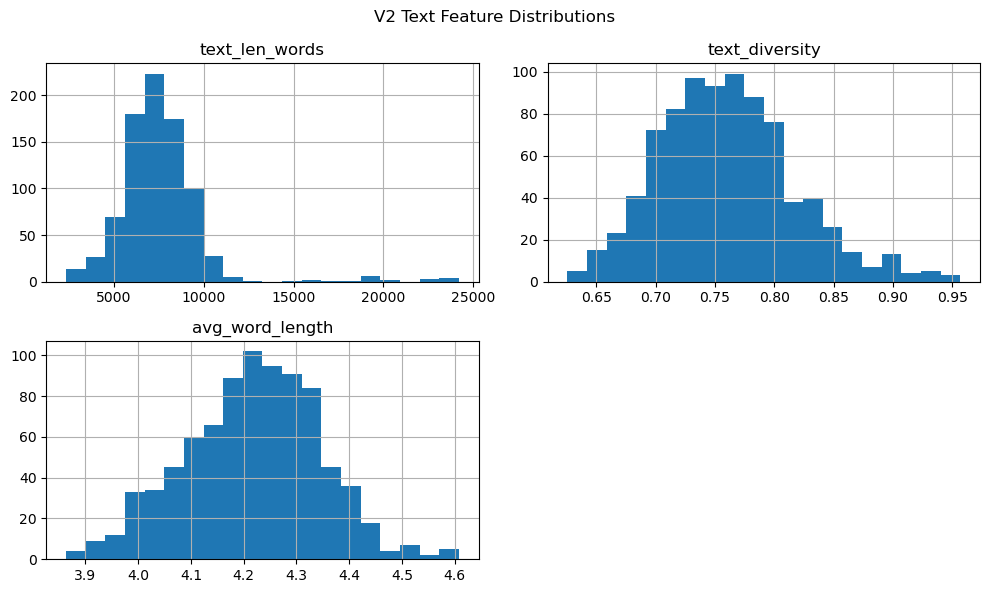

In [42]:
df_model_v2_clean[[
    "text_len_words",
    "text_diversity",
    "avg_word_length"
]].hist(bins=20, figsize=(10, 6))

plt.suptitle("V2 Text Feature Distributions")
plt.tight_layout()
plt.show()

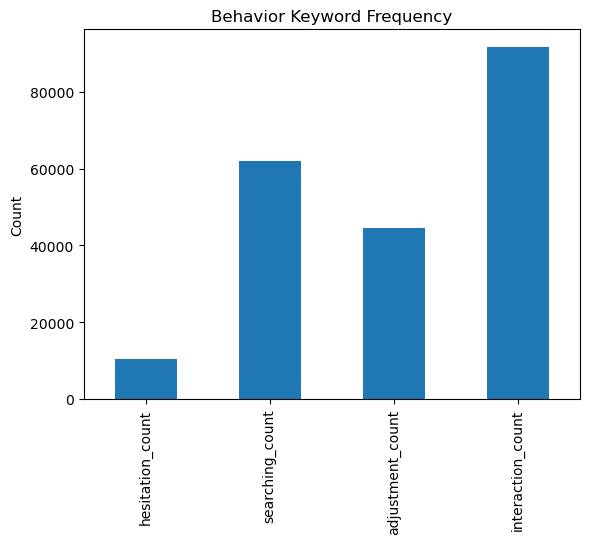

In [43]:
df_atomic_behavior[[
    "hesitation_count",
    "searching_count",
    "adjustment_count",
    "interaction_count"
]].sum().plot(kind="bar")

plt.title("Behavior Keyword Frequency")
plt.ylabel("Count")
plt.show()

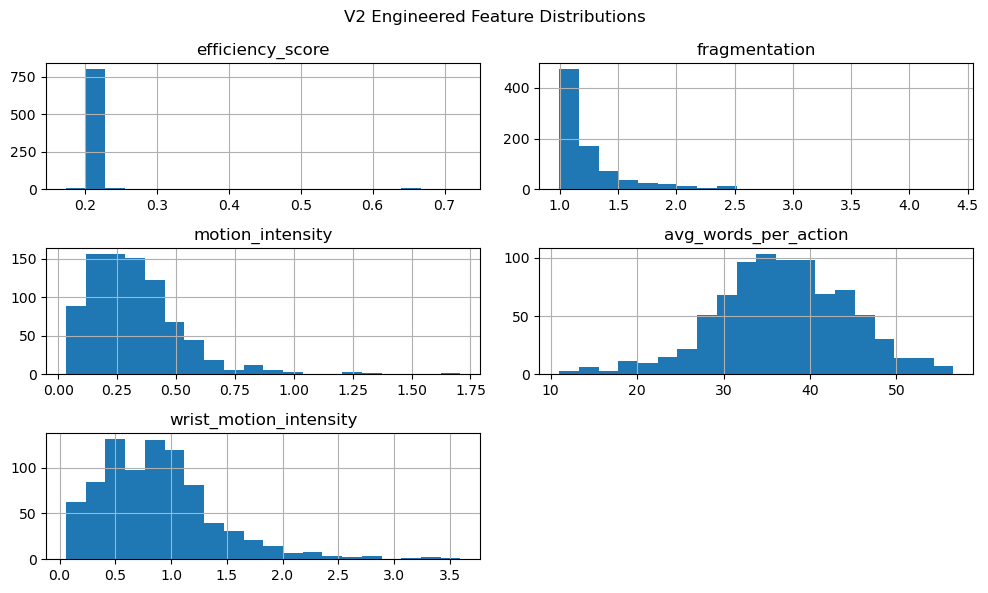

In [44]:
v2_eda_cols = [
    "efficiency_score",
    "fragmentation",
    "motion_intensity",
    "avg_words_per_action",
    "wrist_motion_intensity"
]

df_model_v2_clean[v2_eda_cols].hist(bins=20, figsize=(10, 6))
plt.suptitle("V2 Engineered Feature Distributions")
plt.tight_layout()
plt.show()

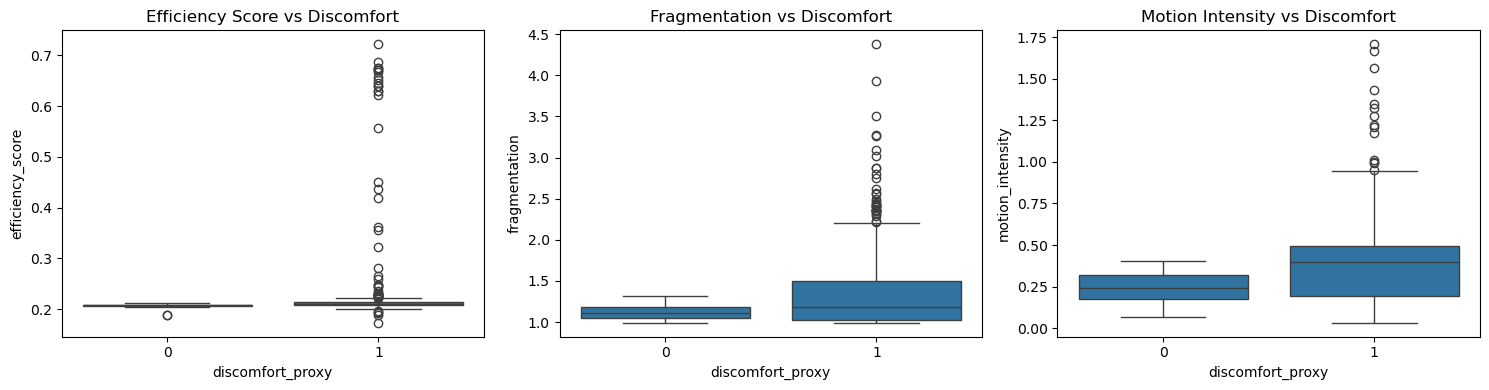

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.boxplot(data=df_model_v2_clean, x="discomfort_proxy", y="efficiency_score", ax=axes[0])
axes[0].set_title("Efficiency Score vs Discomfort")

sns.boxplot(data=df_model_v2_clean, x="discomfort_proxy", y="fragmentation", ax=axes[1])
axes[1].set_title("Fragmentation vs Discomfort")

sns.boxplot(data=df_model_v2_clean, x="discomfort_proxy", y="motion_intensity", ax=axes[2])
axes[2].set_title("Motion Intensity vs Discomfort")

plt.tight_layout()
plt.show()

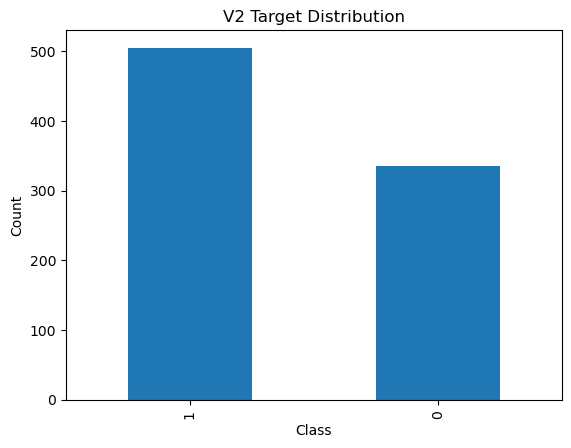

discomfort_proxy
1    0.600476
0    0.399524
Name: proportion, dtype: float64


In [46]:
df_model_v2_clean["discomfort_proxy"].value_counts().plot(kind="bar")
plt.title("V2 Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print(df_model_v2_clean["discomfort_proxy"].value_counts(normalize=True))

Dimensionality Screening

In [47]:
import numpy as np

X_v2_full = df_model_v2_clean[features_v2].copy()

corr_matrix = X_v2_full.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if pd.notnull(val) and val > 0.90:
            high_corr_pairs.append((idx, col, val))

high_corr_pairs[:20]

[('left_wrist_trajectory_m', 'right_wrist_trajectory_m', 0.9826467229653032),
 ('head_trajectory_m', 'observer_trajectory_m', 0.902196890684915),
 ('avg_action_length', 'text_unique_words', 0.9664444948177331),
 ('avg_action_length', 'text_diversity', 0.9313318711488547),
 ('num_actions', 'efficiency_score', 0.9814355699999077),
 ('head_trajectory_m', 'motion_intensity', 0.9946806245467884),
 ('avg_action_length', 'avg_words_per_action', 0.990908579913639),
 ('text_unique_words', 'avg_words_per_action', 0.9714438510709211),
 ('text_diversity', 'avg_words_per_action', 0.9461201751304952),
 ('left_wrist_trajectory_m', 'wrist_motion_total', 0.9957430489898553),
 ('right_wrist_trajectory_m', 'wrist_motion_total', 0.995560452894345),
 ('left_wrist_trajectory_m', 'wrist_motion_intensity', 0.9880157870377991),
 ('right_wrist_trajectory_m', 'wrist_motion_intensity', 0.9846440286066307),
 ('wrist_motion_total', 'wrist_motion_intensity', 0.9906542337931308)]

In [48]:
to_drop_v2 = [col for col in upper.columns if any(upper[col] > 0.90)]
print("Highly correlated features to consider dropping:", to_drop_v2)

Highly correlated features to consider dropping: ['right_wrist_trajectory_m', 'observer_trajectory_m', 'text_unique_words', 'text_diversity', 'efficiency_score', 'motion_intensity', 'avg_words_per_action', 'wrist_motion_total', 'wrist_motion_intensity']


In [49]:
features_v2_reduced = [f for f in features_v2 if f not in to_drop_v2]

print("Original feature count:", len(features_v2))
print("Reduced feature count:", len(features_v2_reduced))
print(features_v2_reduced)

Original feature count: 27
Reduced feature count: 18
['head_trajectory_m', 'head_duration_sec', 'left_wrist_trajectory_m', 'left_wrist_duration_sec', 'right_wrist_duration_sec', 'observer_duration_sec', 'num_actions', 'unique_actions', 'avg_action_duration', 'median_action_duration', 'avg_action_length', 'max_action_length', 'text_len_words', 'avg_word_length', 'fragmentation', 'participant_height_cm', 'participant_weight_kg', 'participant_bmi']


In [50]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    df_model_v2_clean[features_v2],
    df_model_v2_clean["discomfort_proxy"],
    random_state=42
)

mi_df = pd.DataFrame({
    "feature": features_v2,
    "mutual_info": mi_scores
}).sort_values("mutual_info", ascending=False)

mi_df.head(15)

,feature,mutual_info
20,motion_intensity,0.224450
19,fragmentation,0.208250
0,head_trajectory_m,0.171170
22,wrist_motion_total,0.157949
23,wrist_motion_intensity,0.156096
4,right_wrist_trajectory_m,0.155863
18,efficiency_score,0.149058
9,unique_actions,0.143204
2,left_wrist_trajectory_m,0.134659
10,avg_action_duration,0.103694


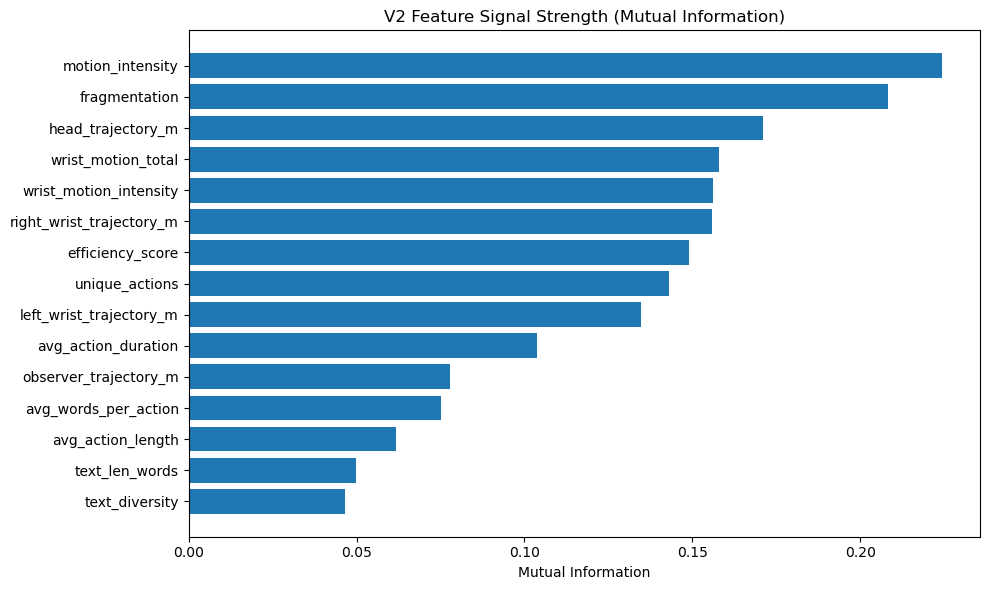

In [51]:
plt.figure(figsize=(10, 6))
plt.barh(mi_df["feature"].head(15)[::-1], mi_df["mutual_info"].head(15)[::-1])
plt.title("V2 Feature Signal Strength (Mutual Information)")
plt.xlabel("Mutual Information")
plt.tight_layout()
plt.show()

In [52]:
from sklearn.model_selection import train_test_split

X_train_v2, X_temp_v2, y_train_v2, y_temp_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=42, stratify=y_v2
)

X_val_v2, X_test_v2, y_val_v2, y_test_v2 = train_test_split(
    X_temp_v2, y_temp_v2, test_size=0.5, random_state=42, stratify=y_temp_v2
)

print("Train V2:", X_train_v2.shape, y_train_v2.shape)
print("Validation V2:", X_val_v2.shape, y_val_v2.shape)
print("Test V2:", X_test_v2.shape, y_test_v2.shape)

Train V2: (672, 27) (672,)
Validation V2: (84, 27) (84,)
Test V2: (85, 27) (85,)


In [53]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf_v2 = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_v2.fit(X_train_v2, y_train_v2)

val_pred_v2 = rf_v2.predict(X_val_v2)
test_pred_v2 = rf_v2.predict(X_test_v2)

print("Validation confusion matrix (V2):")
print(confusion_matrix(y_val_v2, val_pred_v2))
print(classification_report(y_val_v2, val_pred_v2))

print("Test confusion matrix (V2):")
print(confusion_matrix(y_test_v2, test_pred_v2))
print(classification_report(y_test_v2, test_pred_v2))

Validation confusion matrix (V2):
[[34  0]
 [ 0 50]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        34
           1       1.00      1.00      1.00        50

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

Test confusion matrix (V2):
[[33  1]
 [ 0 51]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        34
           1       0.98      1.00      0.99        51

    accuracy                           0.99        85
   macro avg       0.99      0.99      0.99        85
weighted avg       0.99      0.99      0.99        85



In [54]:
importance_df_v2 = pd.DataFrame({
    "feature": X_train_v2.columns,
    "importance": rf_v2.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df_v2.head(15))

                     feature  importance
18          efficiency_score    0.169673
19             fragmentation    0.153860
20          motion_intensity    0.135264
0          head_trajectory_m    0.122218
9             unique_actions    0.083923
22        wrist_motion_total    0.041468
4   right_wrist_trajectory_m    0.040034
10       avg_action_duration    0.038948
2    left_wrist_trajectory_m    0.038141
23    wrist_motion_intensity    0.033649
8                num_actions    0.017569
6      observer_trajectory_m    0.017255
16            text_diversity    0.013917
14            text_len_words    0.010544
21      avg_words_per_action    0.010264


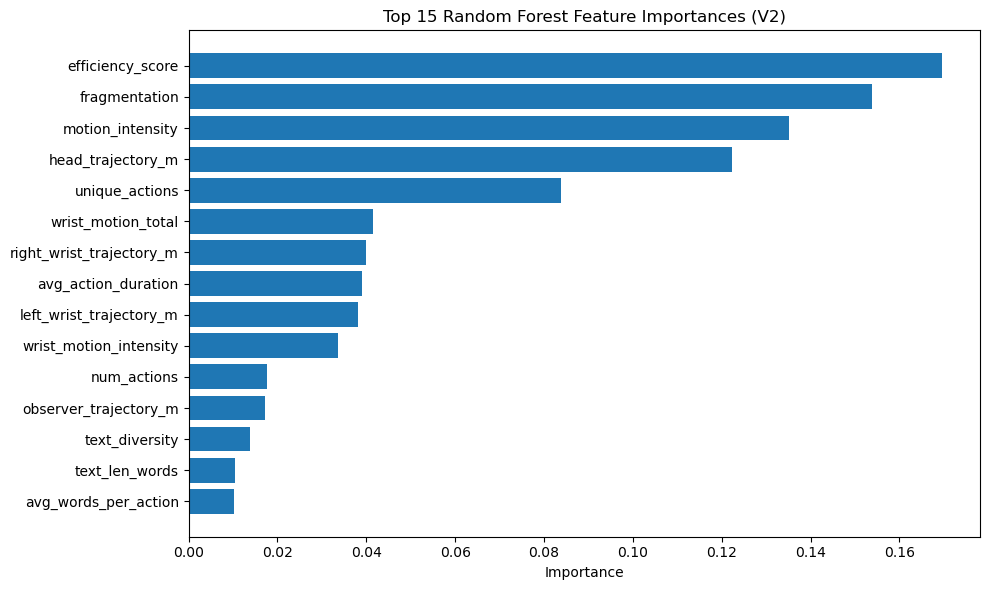

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df_v2["feature"].head(15)[::-1],
    importance_df_v2["importance"].head(15)[::-1]
)
plt.title("Top 15 Random Forest Feature Importances (V2)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

# Final Dataset Preparation for SageMaker Training

In [56]:
features_v2_final = features_v2_reduced.copy()

drop_extra = [
    "text_unique_words",
    "text_diversity",
    "avg_words_per_action"
]

features_v2_final = [f for f in features_v2_final if f not in drop_extra]

print("Final feature count:", len(features_v2_final))
print(features_v2_final)

Final feature count: 18
['head_trajectory_m', 'head_duration_sec', 'left_wrist_trajectory_m', 'left_wrist_duration_sec', 'right_wrist_duration_sec', 'observer_duration_sec', 'num_actions', 'unique_actions', 'avg_action_duration', 'median_action_duration', 'avg_action_length', 'max_action_length', 'text_len_words', 'avg_word_length', 'fragmentation', 'participant_height_cm', 'participant_weight_kg', 'participant_bmi']


In [57]:
X_final = df_model_v2_clean[features_v2_final].copy()
y_final = df_model_v2_clean["discomfort_proxy"].copy()

print("Final feature matrix shape:", X_final.shape)
print("Final target shape:", y_final.shape)
print("Target distribution:")
print(y_final.value_counts())
print(y_final.value_counts(normalize=True))

Final feature matrix shape: (841, 18)
Final target shape: (841,)
Target distribution:
discomfort_proxy
1    505
0    336
Name: count, dtype: int64
discomfort_proxy
1    0.600476
0    0.399524
Name: proportion, dtype: float64


In [58]:
# create train/validation/test split

from sklearn.model_selection import train_test_split

X_train_final, X_temp_final, y_train_final, y_temp_final = train_test_split(
    X_final,
    y_final,
    test_size=0.2,
    random_state=42,
    stratify=y_final
)

X_val_final, X_test_final, y_val_final, y_test_final = train_test_split(
    X_temp_final,
    y_temp_final,
    test_size=0.5,
    random_state=42,
    stratify=y_temp_final
)

print("Train:", X_train_final.shape, y_train_final.shape)
print("Validation:", X_val_final.shape, y_val_final.shape)
print("Test:", X_test_final.shape, y_test_final.shape)

Train: (672, 18) (672,)
Validation: (84, 18) (84,)
Test: (85, 18) (85,)


In [59]:
# Format datasets for Amazon Jumpstart


train_final_df = pd.concat([y_train_final.rename("label"), X_train_final], axis=1)
val_final_df   = pd.concat([y_val_final.rename("label"), X_val_final], axis=1)
test_final_df  = pd.concat([y_test_final.rename("label"), X_test_final], axis=1)

train_final_df.head()

,label,head_trajectory_m,head_duration_sec,left_wrist_trajectory_m,left_wrist_duration_sec,right_wrist_duration_sec,observer_duration_sec,num_actions,unique_actions,avg_action_duration,median_action_duration,avg_action_length,max_action_length,text_len_words,avg_word_length,fragmentation,participant_height_cm,participant_weight_kg,participant_bmi
260,0,260.13,1208.806652,345.61,926.800000,924.900000,1202.140957,186.0,177.0,4.992033,4.999200,210.989247,463.0,7527.0,4.243383,1.044944,155.0,54.0,22.5
636,0,132.53,1113.888511,202.03,987.200000,984.900085,1067.762371,202.0,162.0,4.988476,4.999200,211.638614,526.0,8219.0,4.210285,1.239264,167.0,69.0,24.7
888,0,123.45,1076.394416,120.63,975.700087,983.850000,1064.796366,200.0,193.0,4.988702,4.999200,259.830000,514.0,10543.0,3.954619,1.030928,168.0,59.0,20.9
741,1,522.88,1200.241356,533.73,1025.050000,1029.700071,1179.444686,719.0,717.0,4.659616,4.999198,177.908206,521.0,24208.0,4.326802,1.001393,172.0,73.0,24.7
656,1,458.35,1115.388268,510.89,1002.050000,1004.050000,1083.626592,209.0,170.0,4.881994,4.999199,170.143541,554.0,6750.0,4.307760,1.222222,176.0,59.0,19.1


In [63]:
# (imports consolidated in cell 1)

Libraries loaded.


In [64]:
# Upload to S3
import boto3
import io

s3 = boto3.client("s3")
BUCKET = "sagemaker-bst"
PREFIX = "nymeria/v2/final_training_data"

def upload_df_to_s3(df, bucket, key):
    buffer = io.StringIO()
    df.to_csv(buffer, index=False, header=False)
    s3.put_object(Bucket=bucket, Key=key, Body=buffer.getvalue())

upload_df_to_s3(train_final_df, BUCKET, f"{PREFIX}/train/train.csv")
upload_df_to_s3(val_final_df,   BUCKET, f"{PREFIX}/validation/validation.csv")
upload_df_to_s3(test_final_df,  BUCKET, f"{PREFIX}/test/test.csv")

print("Uploaded:")
print(f"  s3://{BUCKET}/{PREFIX}/train/train.csv")
print(f"  s3://{BUCKET}/{PREFIX}/validation/validation.csv")
print(f"  s3://{BUCKET}/{PREFIX}/test/test.csv")

Uploaded:
  s3://sagemaker-bst/nymeria/v2/final_training_data/train/train.csv
  s3://sagemaker-bst/nymeria/v2/final_training_data/validation/validation.csv
  s3://sagemaker-bst/nymeria/v2/final_training_data/test/test.csv


In [65]:
FEATURE_NAMES = [
    "head_trajectory_m", "head_duration_sec",
    "left_wrist_trajectory_m", "left_wrist_duration_sec",
    "right_wrist_duration_sec", "observer_duration_sec",
    "num_actions", "unique_actions",
    "avg_action_duration", "median_action_duration",
    "avg_action_length", "max_action_length",
    "text_len_words", "avg_word_length",
    "fragmentation", "participant_height_cm",
    "participant_weight_kg", "participant_bmi",
]

def load_from_s3(bucket, key):
    obj = s3.get_object(Bucket=bucket, Key=key)
    df  = pd.read_csv(io.BytesIO(obj["Body"].read()), header=None)
    y   = df.iloc[:, 0]
    X   = df.iloc[:, 1:]
    X.columns = FEATURE_NAMES
    return X, y

X_train_loaded, y_train_loaded = load_from_s3(BUCKET, f"{PREFIX}/train/train.csv")
X_val_loaded,   y_val_loaded   = load_from_s3(BUCKET, f"{PREFIX}/validation/validation.csv")
X_test_loaded,  y_test_loaded  = load_from_s3(BUCKET, f"{PREFIX}/test/test.csv")

print(f"Train : {X_train_loaded.shape} | class dist: {y_train_loaded.value_counts().to_dict()}")
print(f"Val   : {X_val_loaded.shape}   | class dist: {y_val_loaded.value_counts().to_dict()}")
print(f"Test  : {X_test_loaded.shape}  | class dist: {y_test_loaded.value_counts().to_dict()}")

Train : (672, 18) | class dist: {1: 404, 0: 268}
Val   : (84, 18)   | class dist: {1: 50, 0: 34}
Test  : (85, 18)  | class dist: {1: 51, 0: 34}


In [66]:
SEED = 42
cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
all_results = []

def evaluate(name, model, X, y, split="Validation"):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]

    acc  = accuracy_score(y, y_pred)
    f1   = f1_score(y, y_pred)
    auc  = roc_auc_score(y, y_prob)

    print(f"\n{'='*55}")
    print(f"  {name} — {split}")
    print(f"{'='*55}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  F1 Score : {f1:.4f}")
    print(f"  ROC-AUC  : {auc:.4f}")
    print(classification_report(y, y_pred, target_names=["No Discomfort", "Discomfort"]))

    return {"model": name, "accuracy": acc, "f1": f1, "roc_auc": auc}

In [67]:
#XGBoost
xgb_grid = {
    "max_depth"        : [3, 4, 5],
    "learning_rate"    : [0.05, 0.1],
    "subsample"        : [0.7, 0.9],
    "colsample_bytree" : [0.7, 0.9],
    "n_estimators"     : [100, 200],
    "scale_pos_weight" : [1],
}

xgb_search = GridSearchCV(
    xgb.XGBClassifier(objective="binary:logistic", eval_metric="logloss",
                      use_label_encoder=False, random_state=SEED, verbosity=0),
    xgb_grid, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1
)
xgb_search.fit(X_train, y_train)
xgb_best = xgb_search.best_estimator_

print("Best params:", xgb_search.best_params_)
print(f"CV ROC-AUC : {xgb_search.best_score_:.4f}")
xgb_result = evaluate("XGBoost", xgb_best, X_val, y_val)
all_results.append(xgb_result)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best params: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'scale_pos_weight': 1, 'subsample': 0.9}
CV ROC-AUC : 0.9809

  XGBoost — Validation
  Accuracy : 0.9643
  F1 Score : 0.9703
  ROC-AUC  : 0.9965
               precision    recall  f1-score   support

No Discomfort       0.97      0.94      0.96        34
   Discomfort       0.96      0.98      0.97        50

     accuracy                           0.96        84
    macro avg       0.97      0.96      0.96        84
 weighted avg       0.96      0.96      0.96        84



In [68]:
#LightGBM

lgb_grid = {
    "num_leaves"       : [20, 31, 40],
    "max_depth"        : [4, 5, 6],
    "learning_rate"    : [0.05, 0.1],
    "feature_fraction" : [0.7, 0.9],
    "bagging_fraction" : [0.7, 0.9],
    "bagging_freq"     : [1],
    "n_estimators"     : [100, 200],
}

lgb_search = GridSearchCV(
    lgb.LGBMClassifier(objective="binary", random_state=SEED, verbose=-1),
    lgb_grid, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1
)
lgb_search.fit(X_train, y_train)
lgb_best = lgb_search.best_estimator_

print("Best params:", lgb_search.best_params_)
print(f"CV ROC-AUC : {lgb_search.best_score_:.4f}")
lgb_result = evaluate("LightGBM", lgb_best, X_val, y_val)
all_results.append(lgb_result)

Fitting 5 folds for each of 144 candidates, totalling 720 fits
Best params: {'bagging_fraction': 0.7, 'bagging_freq': 1, 'feature_fraction': 0.9, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100, 'num_leaves': 20}
CV ROC-AUC : 0.9798

  LightGBM — Validation
  Accuracy : 0.9524
  F1 Score : 0.9608
  ROC-AUC  : 0.9971
               precision    recall  f1-score   support

No Discomfort       0.97      0.91      0.94        34
   Discomfort       0.94      0.98      0.96        50

     accuracy                           0.95        84
    macro avg       0.96      0.95      0.95        84
 weighted avg       0.95      0.95      0.95        84



In [69]:
#Random Forest
rf_grid = {
    "n_estimators"     : [100, 200],
    "max_depth"        : [5, 7, 10],
    "min_samples_split": [5, 10],
    "min_samples_leaf" : [5, 10],
    "class_weight"     : ["balanced"],
}

rf_search = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_grid, cv=cv, scoring="roc_auc", n_jobs=-1, verbose=1
)
rf_search.fit(X_train, y_train)
rf_best = rf_search.best_estimator_

print("Best params:", rf_search.best_params_)
print(f"CV ROC-AUC : {rf_search.best_score_:.4f}")
rf_result = evaluate("Random Forest", rf_best, X_val, y_val)
all_results.append(rf_result)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 100}
CV ROC-AUC : 0.9794

  Random Forest — Validation
  Accuracy : 0.9524
  F1 Score : 0.9608
  ROC-AUC  : 0.9929
               precision    recall  f1-score   support

No Discomfort       0.97      0.91      0.94        34
   Discomfort       0.94      0.98      0.96        50

     accuracy                           0.95        84
    macro avg       0.96      0.95      0.95        84
 weighted avg       0.95      0.95      0.95        84



               Accuracy  F1 Score  ROC-AUC
model                                     
XGBoost          0.9643    0.9703   0.9965
LightGBM         0.9524    0.9608   0.9971
Random Forest    0.9524    0.9608   0.9929


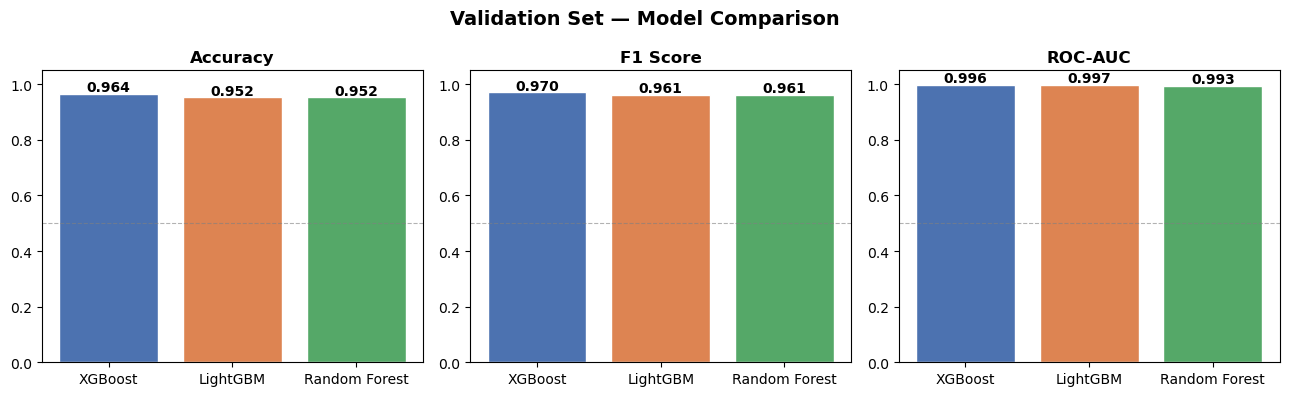

In [70]:
results_df = pd.DataFrame(all_results).set_index("model")
results_df.columns = ["Accuracy", "F1 Score", "ROC-AUC"]
print(results_df.round(4).to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric in zip(axes, ["Accuracy", "F1 Score", "ROC-AUC"]):
    vals = results_df[metric]
    bars = ax.bar(vals.index, vals.values, color=colors, edgecolor="white")
    ax.set_title(metric, fontweight="bold")
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.6)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                v + 0.01, f"{v:.3f}", ha="center", fontsize=10, fontweight="bold")

plt.suptitle("Validation Set — Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

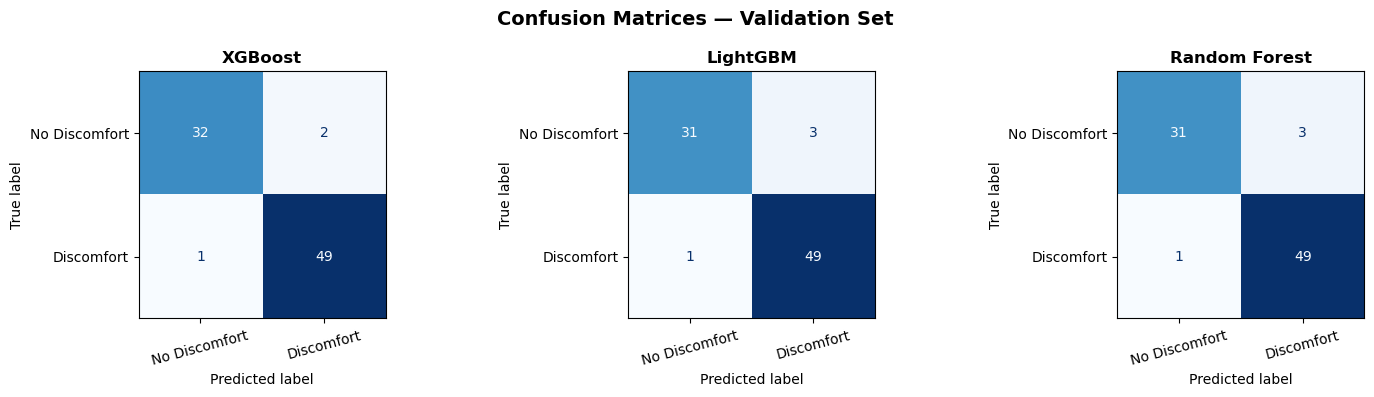

In [71]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, model) in zip(axes, [("XGBoost", xgb_best),
                                      ("LightGBM", lgb_best),
                                      ("Random Forest", rf_best)]):
    cm   = confusion_matrix(y_val, model.predict(X_val))
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Discomfort", "Discomfort"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontweight="bold")
    ax.tick_params(axis="x", labelrotation=15)

plt.suptitle("Confusion Matrices — Validation Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

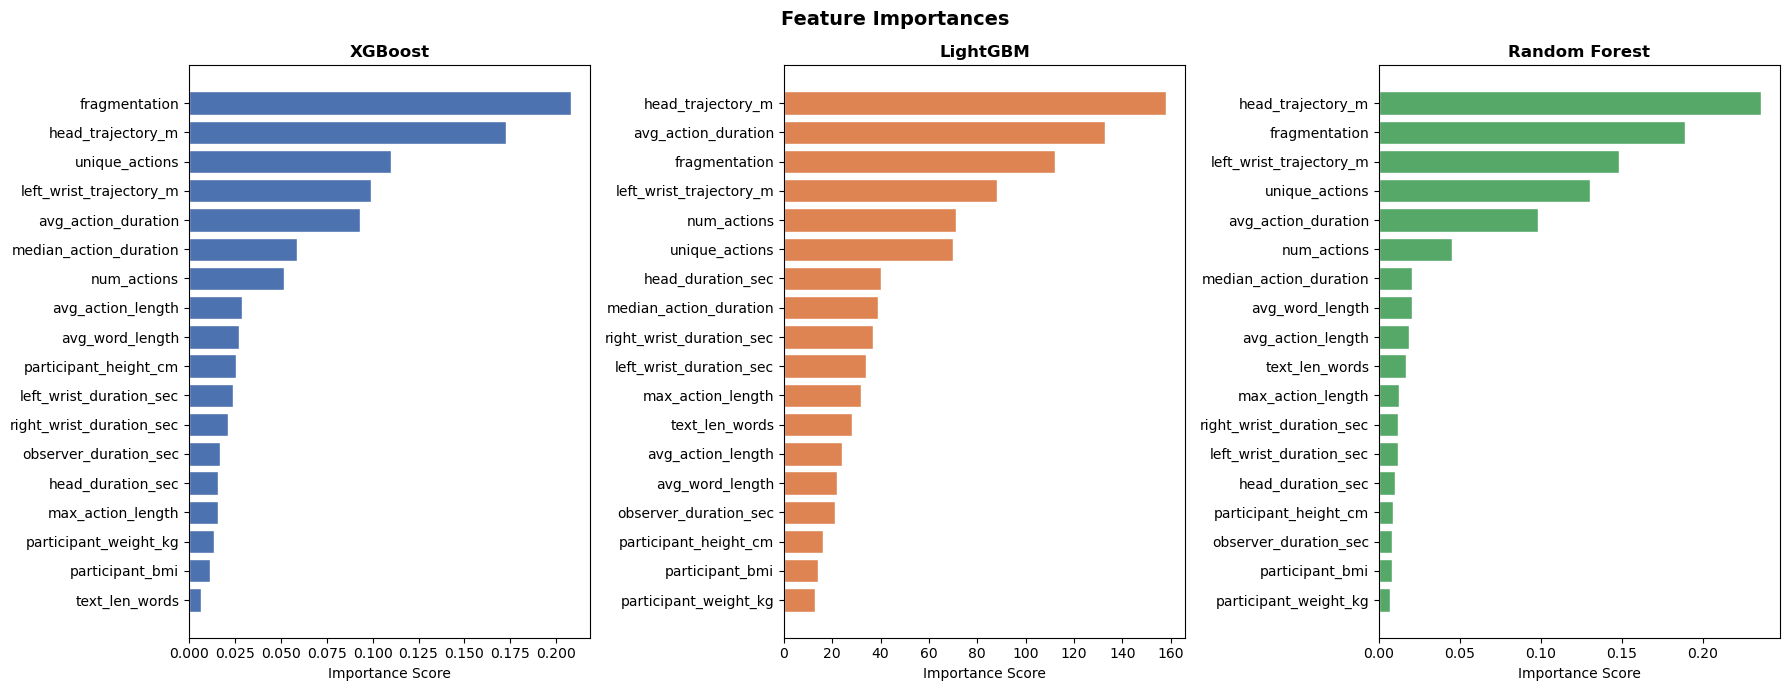

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
for ax, (name, model, color) in zip(axes, [
    ("XGBoost",       xgb_best, "#4C72B0"),
    ("LightGBM",      lgb_best, "#DD8452"),
    ("Random Forest", rf_best,  "#55A868"),
]):
    imp = model.feature_importances_
    idx = np.argsort(imp)
    ax.barh(np.array(FEATURE_NAMES)[idx], imp[idx], color=color, edgecolor="white")
    ax.set_title(name, fontweight="bold")
    ax.set_xlabel("Importance Score")

plt.suptitle("Feature Importances", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [73]:
best_name  = max(all_results, key=lambda r: r["roc_auc"])["model"]
model_map  = {"XGBoost": xgb_best, "LightGBM": lgb_best, "Random Forest": rf_best}
best_model = model_map[best_name]

print(f"Best model by validation ROC-AUC: {best_name}")
test_result = evaluate(best_name, best_model, X_test, y_test, split="Test")

Best model by validation ROC-AUC: LightGBM

  LightGBM — Test
  Accuracy : 0.9412
  F1 Score : 0.9505
  ROC-AUC  : 0.9890
               precision    recall  f1-score   support

No Discomfort       0.91      0.94      0.93        34
   Discomfort       0.96      0.94      0.95        51

     accuracy                           0.94        85
    macro avg       0.94      0.94      0.94        85
 weighted avg       0.94      0.94      0.94        85



## Enhancement 1: SHAP-Based Feature Explanation and Selection

While LightGBM provides built-in feature importance scores, these are based on split frequency or gain and can be unstable across runs. A more robust approach is to apply SHAP (SHapley Additive exPlanations), which assigns each feature a contribution value for every individual prediction rather than a single global score.

For this dataset, SHAP would help answer specific questions that matter for the discomfort classification task — for example, whether `head_trajectory_m` contributes differently for high-BMI participants, or whether `fragmentation` interacts with `num_actions` in a meaningful way. These kinds of interaction effects are invisible in standard importance plots.

From a practical standpoint, SHAP analysis could also guide a second round of feature pruning. If several features consistently show near-zero SHAP values across the test set, removing them may reduce model complexity without sacrificing performance — which matters when deploying in a low-latency environment or retraining frequently on new Nymeria sequences.

## Enhancement 2: Threshold Optimization for Discomfort Detection

The current model uses a default 0.5 probability threshold for classification. However, in the context of physical discomfort detection — where a false negative (missing a participant who is actually in discomfort) carries a higher practical cost than a false positive — the optimal threshold may be lower than 0.5.

Precision-recall curve analysis can be used to identify the threshold that maximizes F1, or alternatively, a cost-sensitive threshold can be selected by defining an explicit misclassification cost ratio between false negatives and false positives. For example, if missing a discomfort case is considered twice as costly as a false alarm, the threshold can be tuned accordingly using the model's `predict_proba` outputs.

This enhancement requires no retraining — it operates entirely on the existing LightGBM model's probability outputs and would be evaluated against the held-out test set. Given the already strong recall on the Discomfort class (0.94), modest threshold adjustment could push recall closer to 0.97–0.98 at an acceptable precision trade-off.

## Enhancement 3: Sequence-Aware Cross-Validation with Participant Stratification

The current train/validation/test split uses random stratified sampling, which means different activity sequences from the same participant (e.g., `james_johnson_act0`, `james_johnson_act1`) can appear in both training and test sets. This introduces a subtle form of data leakage — the model may be partially learning participant-specific movement patterns rather than generalizing to unseen individuals.

A more rigorous evaluation strategy would use GroupKFold or LeaveOneGroupOut cross-validation, where the grouping key is the participant ID extracted from the sequence identifier. This ensures that all sequences from a given participant appear in either the training fold or the validation fold, but never both — simulating the real-world scenario where the model is deployed on a new person it has never seen.

Given that the Nymeria dataset includes anthropometric features like height, weight, and BMI, there is a reasonable risk that the model is currently fitting partially to person-level identity signals. Participant-stratified CV would give a more honest estimate of generalization performance and would be a necessary step before deploying this model in a clinical or ergonomic assessment context.